# Data exploration & baseline model

In this notebook, we'll walk through the Telco Churn dataset. The goal is to get a feel for the data, do some basic cleanup, and train a quick Logistic Regression model to use as a benchmark. 

We'll also introduce **MLflow** for tracking our experiments - specifically how to log parameters, metrics, and any plots or models we generate.

## 1. Setup and imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os

# Make the src/ package importable from notebooks/
REPO_ROOT = os.path.abspath(os.pardir)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import mlflow
import mlflow.sklearn

from src.data_preprocessing import load_data, preprocess, split_data

sns.set_theme(style="whitegrid")
print("MLflow version:", mlflow.__version__)

mlflow.set_tracking_uri(f"sqlite:///{REPO_ROOT}/mlflow.db")

MLflow version: 3.15.2


## 2. Load the data

In [2]:
df = load_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (100000, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,No,No,53,Yes,No,DSL,Yes,No,Yes,No,No,No,Month-to-month,Yes,Mailed check,117.82,6067.93,1
1,Male,0,No,Yes,18,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),41.47,735.23,0
2,Male,0,Yes,No,31,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,Yes,Credit card (automatic),148.51,4695.23,1
3,Male,0,Yes,No,33,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,No,Bank transfer (automatic),148.83,4783.61,1
4,Male,0,No,No,33,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),63.02,2089.60,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            100000 non-null  object 
 1   SeniorCitizen     100000 non-null  int64  
 2   Partner           100000 non-null  object 
 3   Dependents        100000 non-null  object 
 4   tenure            100000 non-null  int64  
 5   PhoneService      100000 non-null  object 
 6   MultipleLines     100000 non-null  object 
 7   InternetService   100000 non-null  object 
 8   OnlineSecurity    100000 non-null  object 
 9   OnlineBackup      100000 non-null  object 
 10  DeviceProtection  100000 non-null  object 
 11  TechSupport       100000 non-null  object 
 12  StreamingTV       100000 non-null  object 
 13  StreamingMovies   100000 non-null  object 
 14  Contract          100000 non-null  object 
 15  PaperlessBilling  100000 non-null  object 
 16  PaymentMethod     100

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.12138,33.681280,131.335455,4452.047971,0.585800
std,0.32657,14.689858,45.914762,2619.964490,0.492586
min,0.00000,0.000000,18.500000,0.000000,0.000000
25%,0.00000,23.000000,111.300000,2292.250000,0.000000
50%,0.00000,33.000000,141.650000,4149.810000,1.000000
75%,0.00000,45.000000,164.510000,6258.255000,1.000000
max,1.00000,71.000000,234.970000,15210.630000,1.000000


## 3. Exploratory data analysis (EDA)

### 3.1 Target distribution (Churn)

In [ ]:
churn_counts = df["Churn"].value_counts()
print("Churn distribution:\n", churn_counts)
print(f"\nChurn rate: {churn_counts[1] / len(df) * 100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Churn", data=df, ax=ax)
ax.set_xticklabels(["No (0)", "Yes (1)"])
ax.set_title("Churn Distribution")
plt.tight_layout()
plt.show()

### 3.2 Numeric feature distributions

In [ ]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_features):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=axes[i])
    axes[i].set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

### 3.3 Categorical feature exploration

In [ ]:
cat_cols = ["gender", "Partner", "Dependents", "PhoneService",
            "InternetService", "Contract", "PaymentMethod"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue="Churn", ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

# Hide the unused subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

### 3.4 Correlation heatmap (numeric features)

In [ ]:
corr_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Preprocessing

We're using the shared `preprocess` and `split_data` functions from `src/data_preprocessing.py` to keep things consistent.

In [6]:
X, y, scaler, feature_names = preprocess(df)
print(f"Features shape: {X.shape}")
print(f"Feature names ({len(feature_names)}): {feature_names}")

Features shape: (100000, 30)
Feature names (30): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [7]:
X_train, X_test, y_train, y_test = split_data(X, y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate:  {y_test.mean():.3f}")

Train: (80000, 30), Test: (20000, 30)
Train churn rate: 0.586
Test churn rate:  0.586


## 5. Baseline model: Logistic Regression

We'll start with a simple Logistic Regression model. It's fast and often good enough to show if our features are actually useful.

In [9]:
# Define hyperparameters
params = {
    "C": 1.0,
    "max_iter": 1000,
    "solver": "lbfgs",
}

# Train the model
model = LogisticRegression(**params, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [10]:
# Evaluate
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

for name, value in metrics.items():
    print(f"  {name}: {value:.4f}")

  accuracy: 0.6805
  precision: 0.7372
  recall: 0.7065
  f1_score: 0.7215
  roc_auc: 0.7304


## 6. MLflow intro: logging your first run

MLflow tracks your work using **experiments** (a collection of related runs) and **runs** (a single execution of your code). It's a great way to keep track of what you've tried so you don't have to manage everything in a spreadsheet.

Here's what we usually log:

- **Parameters**: Input settings like `C=1.0` or `max_iter=1000`.
- **Metrics**: Performance numbers like accuracy or F1 score.
- **Artifacts**: Files like model pickles, plots, or CSVs.
- **Tags**: Labels like `model_type=LogisticRegression` to help with filtering later.

2026/09/01 12:32:24 INFO mlflow.tracking.fluent: Experiment with name 'telco-churn' does not exist. Creating a new experiment.


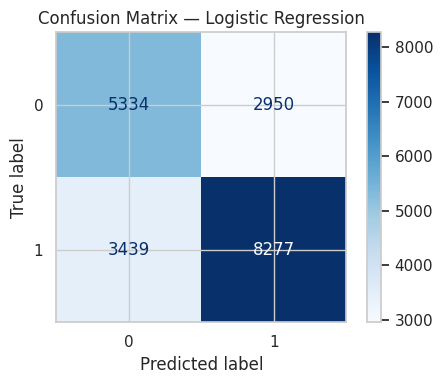


MLflow Run ID: 40c79d225e69481781b815fbf1f6e61f
Run logged successfully!


In [11]:
# ---- Step 1: Set the experiment ----
# All runs below will be grouped under this experiment name.
mlflow.set_experiment("telco-churn")

# ---- Step 2: Start a run ----
with mlflow.start_run(run_name="baseline-logistic-regression"):

    # ---- Step 3: Log parameters ----
    # Parameters are the *inputs* to your training (hyperparameters, etc.)
    mlflow.log_params(params)
    mlflow.log_param("model_type", "LogisticRegression")

    # ---- Step 4: Log metrics ----
    # Metrics are the *outputs* - how well the model performed.
    mlflow.log_metrics(metrics)

    # ---- Step 5: Log the model artifact ----
    # This saves the trained sklearn model so we can reload it later.
    mlflow.sklearn.log_model(
        sk_model=model,
        name="baseline-logistic",
        input_example=X_test.iloc[:5],
    )

    # ---- Step 6: Log a confusion matrix plot as an artifact ----
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
    ax.set_title("Confusion Matrix — Logistic Regression")
    fig.tight_layout()
    mlflow.log_figure(fig, "confusion_matrix.png")
    plt.show()

    # ---- Step 7: Set tags ----
    mlflow.set_tag("model_type", "LogisticRegression")
    mlflow.set_tag("stage", "exploration")

    run_id = mlflow.active_run().info.run_id
    print(f"\nMLflow Run ID: {run_id}")
    print("Run logged successfully!")

## 7. Checking results in the MLflow UI

To see everything you've logged, open a terminal in the project root and run:

```bash
mlflow ui --port 5000
```

Then head over to [http://127.0.0.1:5000](http://127.0.0.1:5000). You should see the **telco-churn** experiment and the run we just finished, complete with all the plots and metrics.